In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(42)   # makes random numbers reproducible

print("All libraries loaded!")

All libraries loaded!


=== Central Tendency ===
Mean:   78.65   ← average
Median: 79.50  ← middle value
Mode:   88     ← most frequent

=== Spread ===
Variance: 116.93  ← average squared distance from mean
Std Dev:  10.81   ← average distance from mean
Range:    40       ← max - min


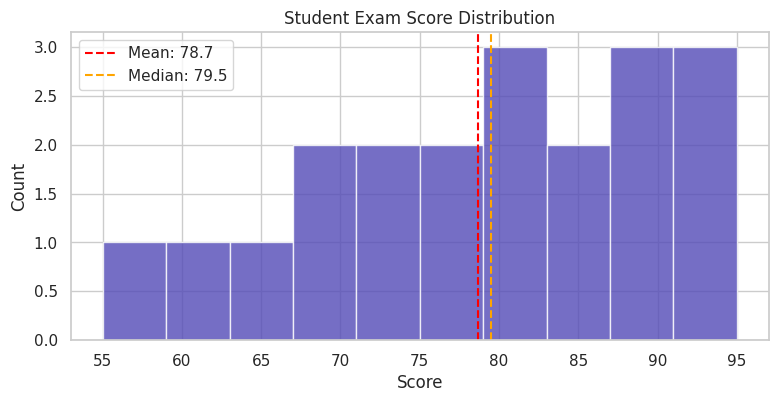

In [2]:
# Exam scores of 20 students
scores = np.array([72, 85, 90, 61, 78, 95, 55, 88, 74, 83,
                   91, 67, 79, 82, 70, 88, 93, 65, 77, 80])

# Central tendency
mean   = np.mean(scores)
median = np.median(scores)
mode   = stats.mode(scores, keepdims=True).mode[0]

# Spread
variance = np.var(scores)
std_dev  = np.std(scores)
rng      = np.max(scores) - np.min(scores)

print("=== Central Tendency ===")
print(f"Mean:   {mean:.2f}   ← average")
print(f"Median: {median:.2f}  ← middle value")
print(f"Mode:   {mode}     ← most frequent")

print("\n=== Spread ===")
print(f"Variance: {variance:.2f}  ← average squared distance from mean")
print(f"Std Dev:  {std_dev:.2f}   ← average distance from mean")
print(f"Range:    {rng}       ← max - min")

# Visualise
plt.figure(figsize=(9, 4))
plt.hist(scores, bins=10, color="#534AB7", edgecolor="white", alpha=0.8)
plt.axvline(mean,   color="red",    linestyle="--", label=f"Mean: {mean:.1f}")
plt.axvline(median, color="orange", linestyle="--", label=f"Median: {median:.1f}")
plt.title("Student Exam Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.legend()
plt.show()

=== Percentiles ===
Q1 (25th percentile): 71.5
Q2 (50th percentile): 79.5
Q3 (75th percentile): 88.0
IQR (Q3 - Q1):        16.5

Outlier boundaries: below 46.8 or above 112.8
Outliers found: []


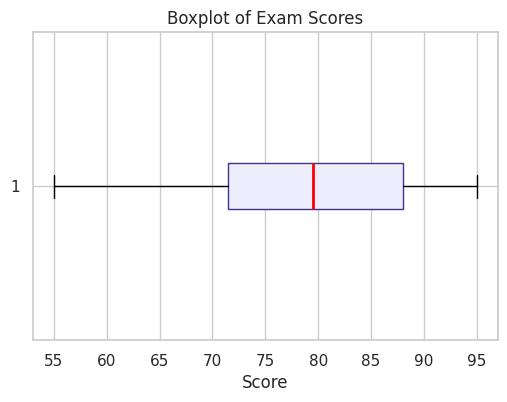

In [3]:
scores = np.array([72, 85, 90, 61, 78, 95, 55, 88, 74, 83,
                   91, 67, 79, 82, 70, 88, 93, 65, 77, 80])

# Percentiles
p25 = np.percentile(scores, 25)   # Q1
p50 = np.percentile(scores, 50)   # Q2 = median
p75 = np.percentile(scores, 75)   # Q3
iqr = p75 - p25                   # interquartile range

print("=== Percentiles ===")
print(f"Q1 (25th percentile): {p25}")
print(f"Q2 (50th percentile): {p50}")
print(f"Q3 (75th percentile): {p75}")
print(f"IQR (Q3 - Q1):        {iqr}")

# Outlier boundaries using IQR rule
lower = p25 - 1.5 * iqr
upper = p75 + 1.5 * iqr
print(f"\nOutlier boundaries: below {lower:.1f} or above {upper:.1f}")

outliers = scores[(scores < lower) | (scores > upper)]
print(f"Outliers found: {outliers}")

# Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(scores, vert=False, patch_artist=True,
            boxprops=dict(facecolor="#EEEDFE", color="#3C3489"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Boxplot of Exam Scores")
plt.xlabel("Score")
plt.show()


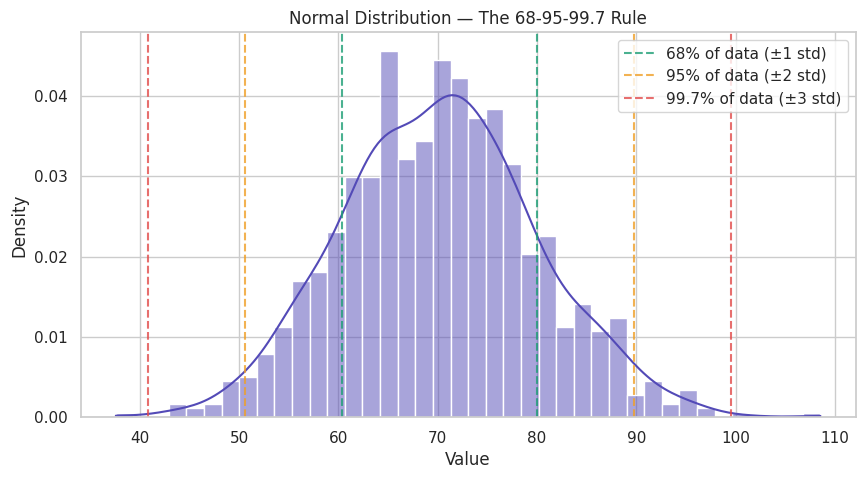

Mean: 70.19  |  Std Dev: 9.79
Data within 1 std: 68.6%
Data within 2 std: 95.6%
Data within 3 std: 99.7%


In [4]:
# Generate normally distributed data
# Mean = 70, Std = 10, 1000 data points
data = np.random.normal(loc=70, scale=10, size=1000)

plt.figure(figsize=(10, 5))

# Histogram + KDE
sns.histplot(data, bins=40, kde=True, color="#534AB7",
             edgecolor="white", stat="density")

# Mark standard deviation zones
mean, std = np.mean(data), np.std(data)
colors = ["#1D9E75", "#EF9F27", "#E24B4A"]
labels = ["68% of data (±1 std)", "95% of data (±2 std)", "99.7% of data (±3 std)"]

for i, (c, lbl) in enumerate(zip(colors, labels), 1):
    plt.axvline(mean + i*std, color=c, linestyle="--", alpha=0.8)
    plt.axvline(mean - i*std, color=c, linestyle="--", alpha=0.8, label=lbl)

plt.title("Normal Distribution — The 68-95-99.7 Rule")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

print(f"Mean: {mean:.2f}  |  Std Dev: {std:.2f}")
print(f"Data within 1 std: {np.mean(np.abs(data - mean) <= std)*100:.1f}%")
print(f"Data within 2 std: {np.mean(np.abs(data - mean) <= 2*std)*100:.1f}%")
print(f"Data within 3 std: {np.mean(np.abs(data - mean) <= 3*std)*100:.1f}%")

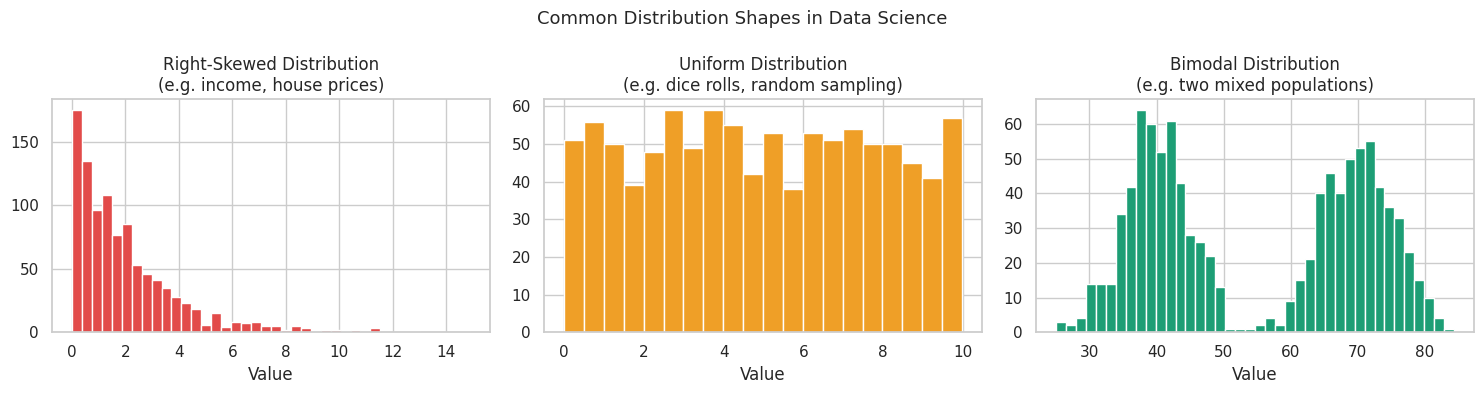

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. SKEWED distribution (e.g. income, house prices)
skewed = np.random.exponential(scale=2, size=1000)
axes[0].hist(skewed, bins=40, color="#E24B4A", edgecolor="white")
axes[0].set_title("Right-Skewed Distribution\n(e.g. income, house prices)")
axes[0].set_xlabel("Value")

# 2. UNIFORM distribution (e.g. rolling a dice)
uniform = np.random.uniform(low=0, high=10, size=1000)
axes[1].hist(uniform, bins=20, color="#EF9F27", edgecolor="white")
axes[1].set_title("Uniform Distribution\n(e.g. dice rolls, random sampling)")
axes[1].set_xlabel("Value")

# 3. BIMODAL distribution (e.g. two groups mixed)
group1 = np.random.normal(40, 5, 500)
group2 = np.random.normal(70, 5, 500)
bimodal = np.concatenate([group1, group2])
axes[2].hist(bimodal, bins=40, color="#1D9E75", edgecolor="white")
axes[2].set_title("Bimodal Distribution\n(e.g. two mixed populations)")
axes[2].set_xlabel("Value")

plt.suptitle("Common Distribution Shapes in Data Science", fontsize=13)
plt.tight_layout()
plt.show()

Score  →  Z-score  →  Interpretation
---------------------------------------------
  72    →   -0.61     →  near average
  85    →   +0.59     →  near average
  90    →   +1.05     →  above average
  61    →   -1.63     →  below average
  78    →   -0.06     →  near average
  95    →   +1.51     →  above average
  55    →   -2.19     →  below average
  88    →   +0.86     →  near average


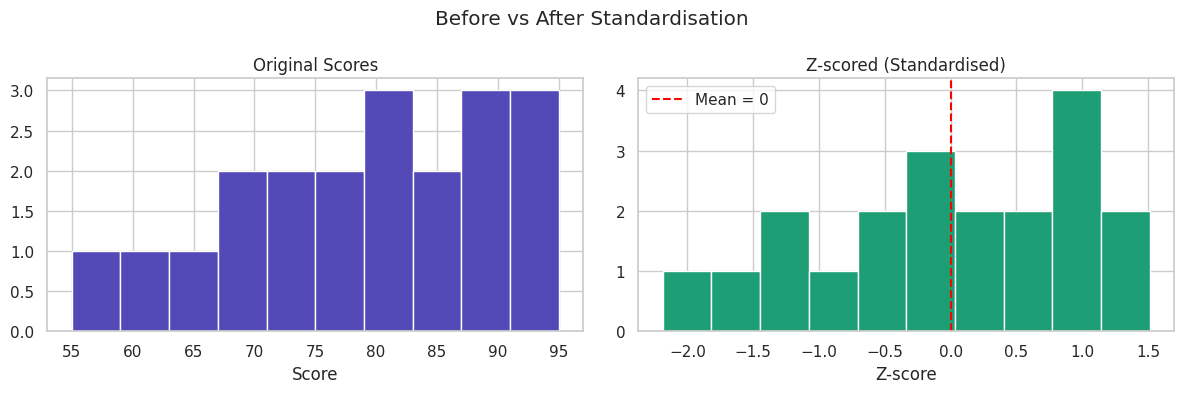

In [6]:
scores = np.array([72, 85, 90, 61, 78, 95, 55, 88, 74, 83,
                   91, 67, 79, 82, 70, 88, 93, 65, 77, 80])

# Z-score = (value - mean) / std_dev
# Tells you: how many std deviations is this value from the mean?
z_scores = stats.zscore(scores)

print("Score  →  Z-score  →  Interpretation")
print("-" * 45)
for s, z in zip(scores[:8], z_scores[:8]):
    if z > 1:   interp = "above average"
    elif z < -1: interp = "below average"
    else:        interp = "near average"
    print(f"  {s}    →   {z:+.2f}     →  {interp}")

# Visualise original vs standardised
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(scores, bins=10, color="#534AB7", edgecolor="white")
ax1.set_title("Original Scores")
ax1.set_xlabel("Score")

ax2.hist(z_scores, bins=10, color="#1D9E75", edgecolor="white")
ax2.axvline(0, color="red", linestyle="--", label="Mean = 0")
ax2.set_title("Z-scored (Standardised)")
ax2.set_xlabel("Z-score")
ax2.legend()

plt.suptitle("Before vs After Standardisation")
plt.tight_layout()
plt.show()

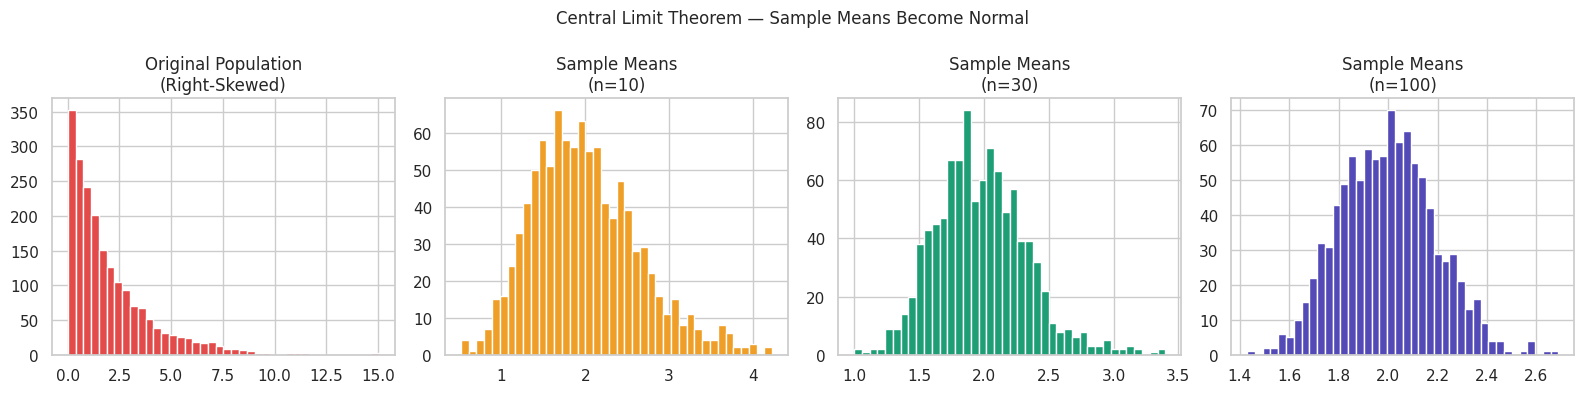

CLT says: no matter how skewed your data is,
the distribution of SAMPLE MEANS will be normal
as long as sample size >= 30.


In [7]:
# CLT: sample means are normally distributed
# even if the original data is NOT normal

# Start with skewed (non-normal) population
population = np.random.exponential(scale=2, size=100000)

# Take many samples and record their means
sample_means_10  = [np.mean(np.random.choice(population, 10))  for _ in range(1000)]
sample_means_30  = [np.mean(np.random.choice(population, 30))  for _ in range(1000)]
sample_means_100 = [np.mean(np.random.choice(population, 100)) for _ in range(1000)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(population[:2000], bins=40, color="#E24B4A", edgecolor="white")
axes[0].set_title("Original Population\n(Right-Skewed)")

for ax, means, n, c in zip(axes[1:],
    [sample_means_10, sample_means_30, sample_means_100],
    [10, 30, 100],
    ["#EF9F27", "#1D9E75", "#534AB7"]):
    ax.hist(means, bins=40, color=c, edgecolor="white")
    ax.set_title(f"Sample Means\n(n={n})")

plt.suptitle("Central Limit Theorem — Sample Means Become Normal", fontsize=12)
plt.tight_layout()
plt.show()

print("CLT says: no matter how skewed your data is,")
print("the distribution of SAMPLE MEANS will be normal")
print("as long as sample size >= 30.")